# Churn Prediction — Data Understanding
**Universidad Alfonso X el Sabio (UAX)**


En este notebook exploramos el dataset de clientes de un concesionario de automóviles para entender qué factores se relacionan con el **churn** (abandono del cliente). El objetivo es identificar patrones que ayuden a predecir qué clientes dejarán de volver al taller o no realizarán una segunda compra.


## 1. Librerías y configuración visual


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Paleta corporativa UAX ──────────────────────────────────
UAX_NAVY    = '#1B2A4A'   # azul oscuro principal
UAX_GOLD    = '#C8A951'   # dorado corporativo
UAX_LIGHT   = '#E8E0D0'   # beige claro fondo
UAX_GREY    = '#6B7B8D'   # gris complementario
UAX_ACCENT  = '#3A5BA0'   # azul medio para contraste

uax_palette = [UAX_NAVY, UAX_GOLD, UAX_ACCENT, UAX_GREY]

# ── Estilo global para TODAS las gráficas ───────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.edgecolor':   UAX_GREY,
    'axes.labelcolor':  UAX_NAVY,
    'text.color':       UAX_NAVY,
    'xtick.color':      UAX_GREY,
    'ytick.color':      UAX_GREY,
    'grid.color':       '#E0E0E0',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'figure.titlesize': 16,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  UAX_GREY,
})

sns.set_style('white')
print('✓ Configuración visual UAX cargada')


✓ Configuración visual UAX cargada


## 2. Carga de datos


In [2]:
customer_data = pd.read_csv('data/lake/customer_data.csv')
print(f'Registros: {customer_data.shape[0]:,}  |  Variables: {customer_data.shape[1]}')
customer_data.head(3)


Registros: 58,049  |  Variables: 40


,CODE,Sales_Date,Id_Producto,Customer_ID,PVP,MOTIVO_VENTA,FORMA_PAGO,EXTENSION_GARANTIA,SEGURO_BATERIA_LARGO_PLAZO,MANTENIMIENTO_GRATUITO,...,Lead_compra,Fue_Lead,TIENDA_DESC,PROV_DESC,ZONA,Origen,Margen_eur_bruto,Margen_eur,DAYS_LAST_SERVICE,Churn_400
0,ID22371,14/03/2022,PA100006,70426,10528,Particular,Financiera Marca,NO,NO,0,...,0,0,BILBAO,BILBAO,NORTE,Tienda,2328.79,1247.08,117.0,N
1,ID22373,20/06/2023,PA100006,53124,10528,Particular,Contado,NO,NO,0,...,0,1,BARCELONA NORTE,BARCELONA,ESTE,Internet,2328.79,1247.08,NaN,N
2,ID22380,21/03/2021,PA100006,39623,10528,Particular,Contado,NO,NO,0,...,0,0,MADRID SUR,MADRID,CENTRO,Tienda,2328.79,1247.08,NaN,N


## 3. Primera vista del dataset


Antes de hacer gráficas, conviene entender la estructura: qué tipos de variables tenemos, cuántos nulos hay y las estadísticas básicas.


In [3]:
# Tipos de columnas
num_cols = customer_data.select_dtypes(include='number').columns.tolist()
cat_cols = customer_data.select_dtypes(include=['object', 'string']).columns.tolist()

print(f'Variables numéricas ({len(num_cols)}): {num_cols}')
print(f'Variables categóricas ({len(cat_cols)}): {cat_cols}')


Variables numéricas (16): ['Customer_ID', 'PVP', 'MANTENIMIENTO_GRATUITO', 'COSTE_VENTA_NO_IMPUESTOS', 'Edad', 'RENTA_MEDIA_ESTIMADA', 'ENCUESTA_CLIENTE_ZONA_TALLER', 'Kw', 'Revisiones', 'Km_medio_por_revision', 'km_ultima_revision', 'Lead_compra', 'Fue_Lead', 'Margen_eur_bruto', 'Margen_eur', 'DAYS_LAST_SERVICE']
Variables categóricas (24): ['CODE', 'Sales_Date', 'Id_Producto', 'MOTIVO_VENTA', 'FORMA_PAGO', 'EXTENSION_GARANTIA', 'SEGURO_BATERIA_LARGO_PLAZO', 'FIN_GARANTIA', 'BASE_DATE', 'EN_GARANTIA', 'GENERO', 'CODIGO_POSTAL', 'STATUS_SOCIAL', 'Modelo', 'TIPO_CARROCERIA', 'Fuel', 'TRANSMISION_ID', 'Equipamiento', 'QUEJA', 'TIENDA_DESC', 'PROV_DESC', 'ZONA', 'Origen', 'Churn_400']


In [4]:
# Nulos por columna (solo las que tienen)
nulos = customer_data.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
nulos_pct = (nulos / len(customer_data) * 100).round(1)

df_nulos = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
print(df_nulos.to_string())


                   Nulos  % del total
QUEJA              33323         57.4
DAYS_LAST_SERVICE  27070         46.6
STATUS_SOCIAL      12816         22.1
GENERO               849          1.5


Hay tres variables con nulos relevantes: `DAYS_LAST_SERVICE` (casi la mitad del dataset), `STATUS_SOCIAL` (22%) y `QUEJA` (57%). `GENERO` tiene un porcentaje bajo y se puede imputar fácilmente. Las demás están completas.


## 4. Variable objetivo — Churn


Lo primero y más importante: ver cómo se distribuye la variable que queremos predecir. Un dataset muy desbalanceado condiciona toda la estrategia de modelado.


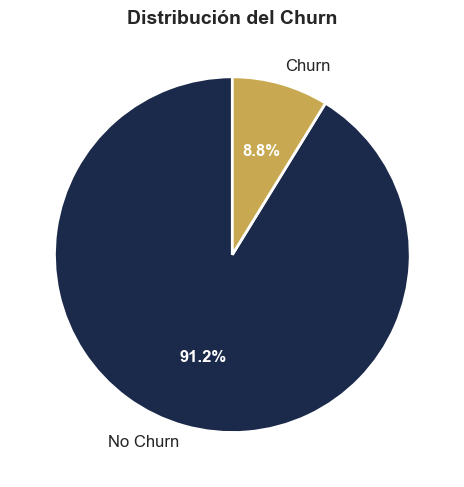

Tasa de churn: 8.8%


In [5]:
# Preparar target como numérico para análisis
customer_data['Churn_flag'] = (customer_data['Churn_400'] == 'Y').astype(int)

churn_counts = customer_data['Churn_400'].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    churn_counts.values,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=[UAX_NAVY, UAX_GOLD],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for t in autotexts:
    t.set_color('white')
    t.set_fontweight('bold')
ax.set_title('Distribución del Churn')
plt.tight_layout()
plt.show()

print(f'Tasa de churn: {churn_counts.get("Y", 0) / len(customer_data) * 100:.1f}%')


El dataset está **muy desbalanceado**: solo ~8-9% de los clientes hacen churn. Esto es habitual en problemas de retención. Habrá que tenerlo en cuenta a la hora de entrenar modelos (técnicas como SMOTE, ajuste de pesos, etc.).


## 5. Distribución de variables numéricas clave


Veamos cómo se distribuyen las principales variables numéricas y si hay diferencias entre clientes que hacen churn y los que no.


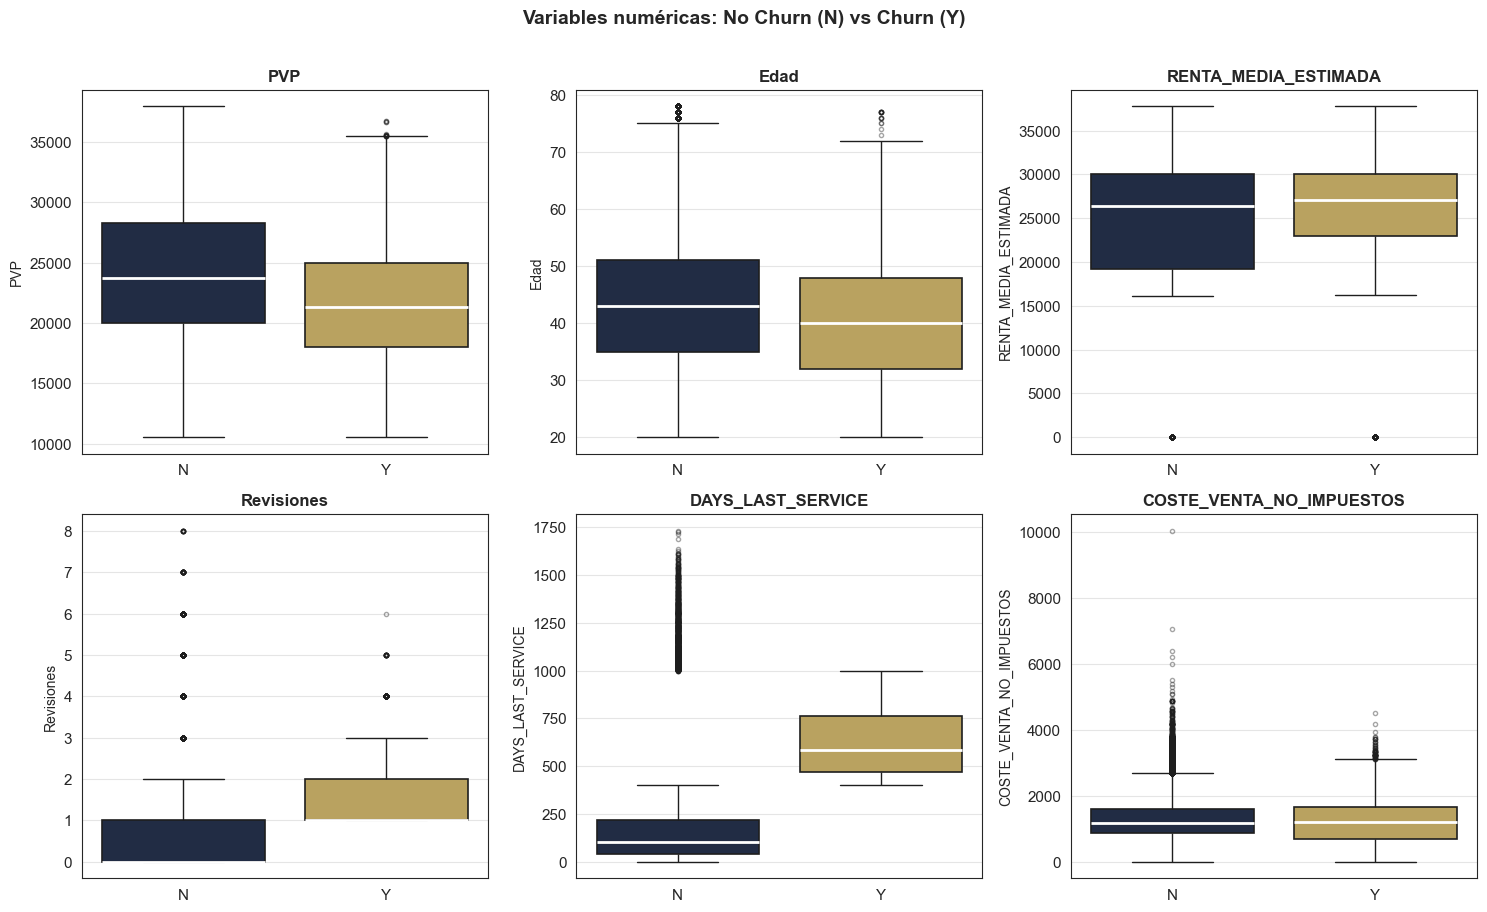

In [6]:
key_num = ['PVP', 'Edad', 'RENTA_MEDIA_ESTIMADA', 'Revisiones', 'DAYS_LAST_SERVICE', 'COSTE_VENTA_NO_IMPUESTOS']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, var in enumerate(key_num):
    ax = axes[i]
    sns.boxplot(
        x='Churn_400', y=var, data=customer_data,
        palette=[UAX_NAVY, UAX_GOLD], ax=ax,
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4},
        boxprops={'linewidth': 1.2},
        medianprops={'color': 'white', 'linewidth': 2}
    )
    ax.set_xlabel('')
    ax.set_ylabel(var, fontsize=10)
    ax.set_title(var, fontsize=12)
    ax.grid(axis='y')

plt.suptitle('Variables numéricas: No Churn (N) vs Churn (Y)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Lo que vemos:

- **PVP**: Los clientes que hacen churn compran coches de precio similar a los que se quedan. No parece un factor diferenciador fuerte.
- **Edad**: Distribución muy parecida en ambos grupos.
- **RENTA_MEDIA_ESTIMADA**: Similar entre ambos grupos, aunque los churners parecen tener mediana ligeramente inferior.
- **Revisiones**: Los clientes que se quedan tienden a tener más revisiones. Esto tiene sentido: quien lleva su coche a revisiones mantiene la relación con el taller.
- **DAYS_LAST_SERVICE**: Los clientes churn llevan más tiempo sin venir al taller. Tiene mucho sentido como indicador.
- **COSTE_VENTA_NO_IMPUESTOS**: Sin diferencias claras.


## 6. Días desde el último servicio — Factor clave


Esta variable parece la más intuitiva: si un cliente lleva mucho tiempo sin pasar por el taller, es más probable que ya no vuelva. Veámoslo en detalle.


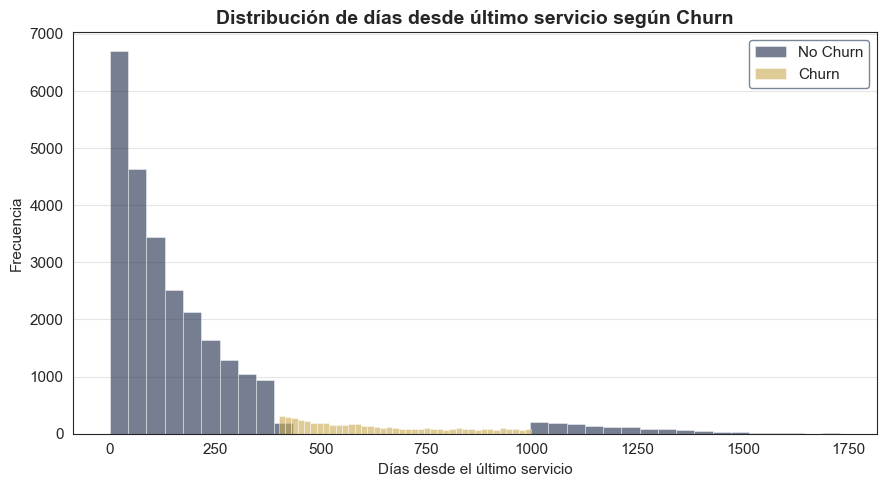

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, color in [('N', UAX_NAVY), ('Y', UAX_GOLD)]:
    subset = customer_data[customer_data['Churn_400'] == label]['DAYS_LAST_SERVICE'].dropna()
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=f'{"Churn" if label == "Y" else "No Churn"}', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Días desde el último servicio')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de días desde último servicio según Churn')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.show()


Se confirma: los clientes que hacen **churn** (dorado) se concentran en valores altos de días sin servicio. Los que **se quedan** (azul oscuro) suelen tener visitas más recientes. Esta variable será probablemente una de las más predictivas del modelo.


## 7. Garantía y Churn


¿Los clientes cuya garantía ha expirado abandonan más? Crucemos las dos variables.


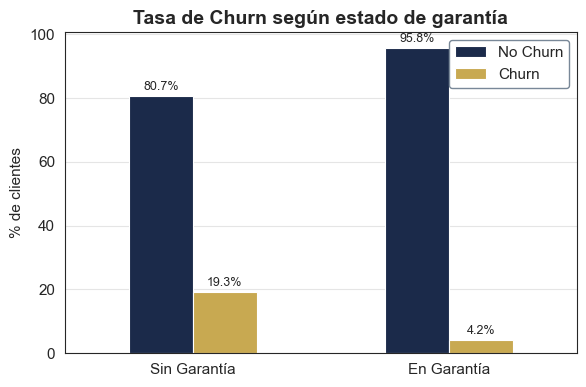

In [8]:
ct = pd.crosstab(customer_data['EN_GARANTIA'], customer_data['Churn_400'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(6, 4))
ct.plot(kind='bar', color=[UAX_NAVY, UAX_GOLD], ax=ax, edgecolor='white', linewidth=0.8)
ax.set_title('Tasa de Churn según estado de garantía')
ax.set_xlabel('')
ax.set_ylabel('% de clientes')
ax.set_xticklabels(['Sin Garantía', 'En Garantía'], rotation=0)
ax.legend(['No Churn', 'Churn'], loc='upper right')
ax.grid(axis='y')

# Anotar porcentajes
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=2)

plt.tight_layout()
plt.show()


Los clientes **sin garantía** tienen una tasa de churn del ~19%, frente al ~4% de los que aún están en garantía. Esto tiene mucho sentido: una vez caduca la garantía, el cliente pierde un incentivo para volver al taller oficial.


## 8. Variables categóricas y su relación con el Churn


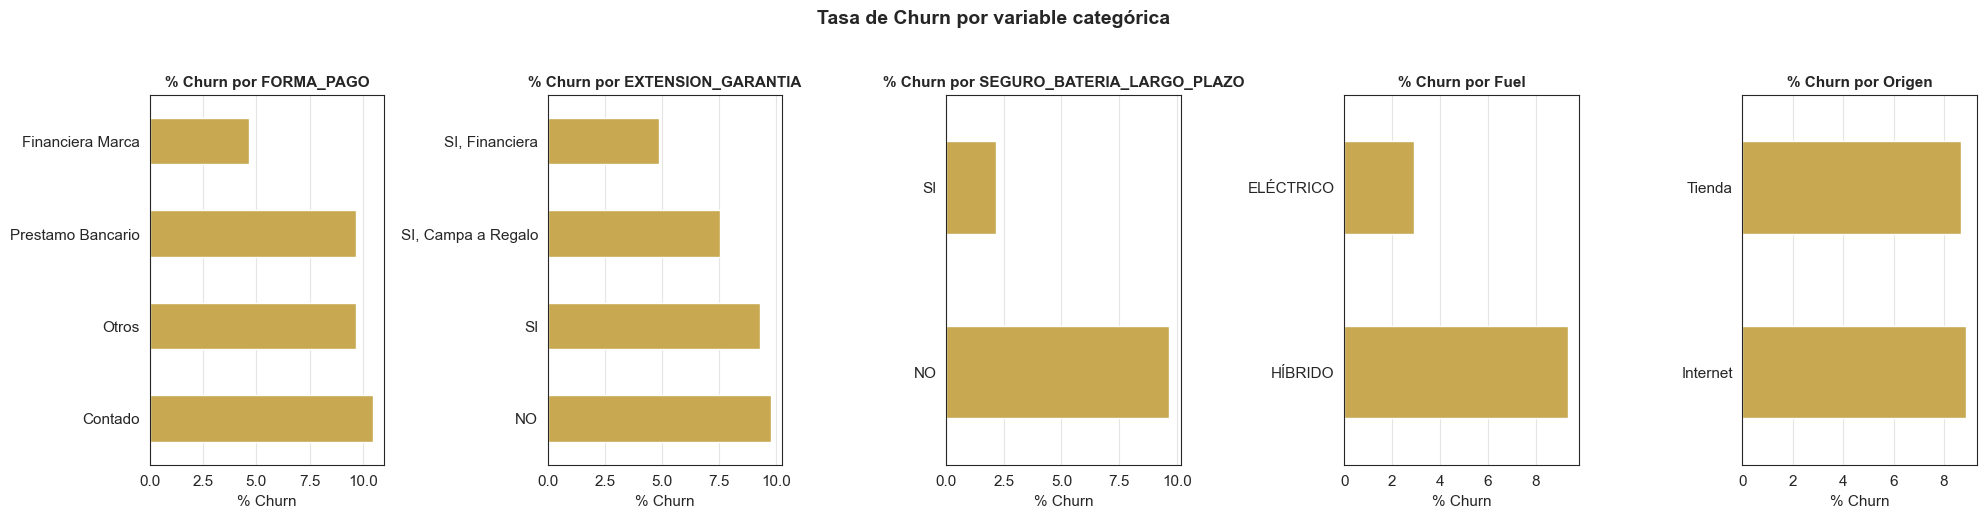

In [9]:
cat_vars = ['FORMA_PAGO', 'EXTENSION_GARANTIA', 'SEGURO_BATERIA_LARGO_PLAZO', 'Fuel', 'Origen']

fig, axes = plt.subplots(1, len(cat_vars), figsize=(20, 5))

for i, var in enumerate(cat_vars):
    ax = axes[i]
    ct = pd.crosstab(customer_data[var], customer_data['Churn_400'], normalize='index') * 100
    ct['Y'].sort_values(ascending=False).plot(
        kind='barh', color=UAX_GOLD, ax=ax, edgecolor='white'
    )
    ax.set_title(f'% Churn por {var}', fontsize=11)
    ax.set_xlabel('% Churn')
    ax.set_ylabel('')
    ax.grid(axis='x')

plt.suptitle('Tasa de Churn por variable categórica', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


Observaciones:

- **Forma de pago**: Los clientes que pagan al contado tienen mayor tasa de churn. Los que financian a través de la marca están más vinculados y abandonan menos.
- **Extensión de garantía**: No contratar extensión de garantía se asocia a más churn.
- **Seguro batería**: Similar al anterior — no contratarlo eleva el riesgo de abandono.
- **Fuel**: Las diferencias por combustible son menores, pero existen matices.
- **Origen**: Los clientes captados por Internet muestran algo más de churn que los de tienda.


## 9. Análisis geográfico


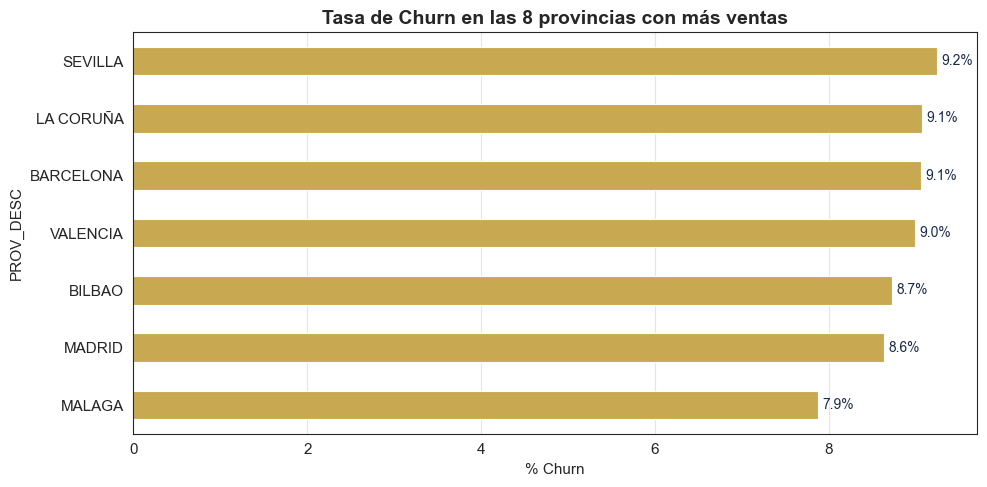

In [17]:
# Top provincias por volumen
top_prov = customer_data['PROV_DESC'].value_counts().head(8).index

df_top = customer_data[customer_data['PROV_DESC'].isin(top_prov)]
ct_geo = pd.crosstab(df_top['PROV_DESC'], df_top['Churn_400'], normalize='index') * 100
ct_geo = ct_geo.sort_values('Y', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ct_geo['Y'].plot(kind='barh', color=UAX_GOLD, ax=ax, edgecolor='white', linewidth=0.8)
ax.set_xlabel('% Churn')
ax.set_title('Tasa de Churn en las 8 provincias con más ventas')
ax.grid(axis='x')

for i, v in enumerate(ct_geo['Y']):
    ax.text(v +0.05, i, f'{v:.1f}%', va='center', fontsize=10, color=UAX_NAVY)

plt.tight_layout()
plt.show()


Las diferencias geográficas existen pero no son dramáticas. Aun así, puede ser útil incluir la zona como variable en el modelo.


## 10. Correlaciones numéricas


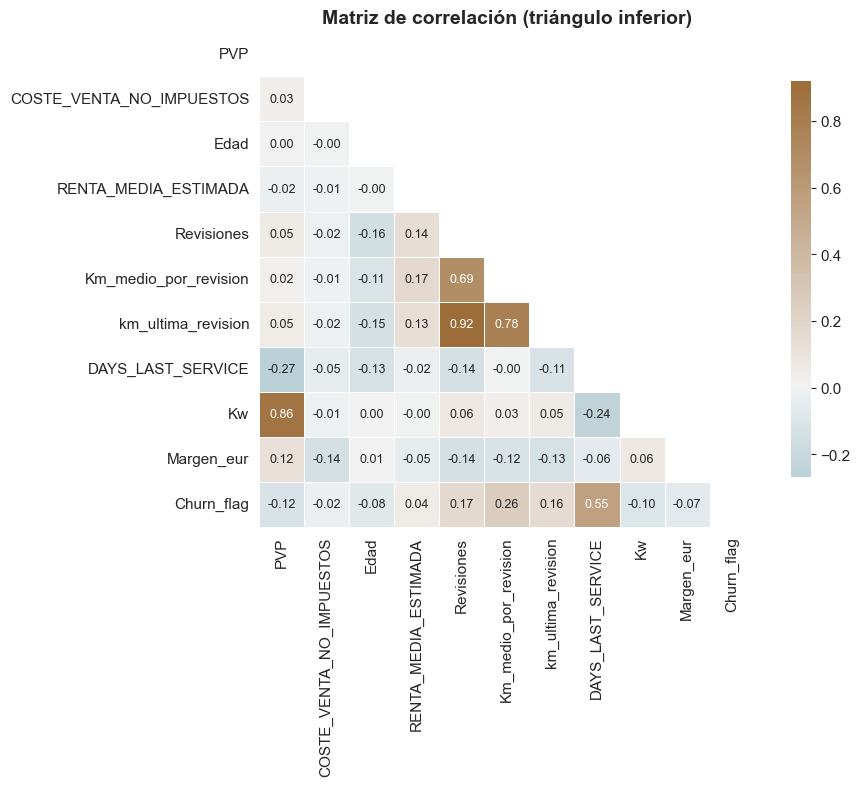

In [18]:
num_for_corr = ['PVP', 'COSTE_VENTA_NO_IMPUESTOS', 'Edad', 'RENTA_MEDIA_ESTIMADA',
                'Revisiones', 'Km_medio_por_revision', 'km_ultima_revision',
                'DAYS_LAST_SERVICE', 'Kw', 'Margen_eur', 'Churn_flag']

corr = customer_data[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(220, 45, as_cmap=True)  # azul-dorado
sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0,
    annot=True, fmt='.2f', linewidths=0.5,
    square=True, ax=ax,
    annot_kws={'fontsize': 9},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlación (triángulo inferior)')
plt.tight_layout()
plt.show()


Puntos destacados de la correlación:

- **DAYS_LAST_SERVICE** tiene correlación positiva con Churn: a más días sin servicio, más probabilidad de abandono.
- **Revisiones** tiene correlación negativa con Churn: más revisiones → menos abandono.
- **PVP y Kw** están correlacionados entre sí (coches más potentes cuestan más), pero ninguno tiene fuerte relación con el churn.
- No hay multicolinealidad preocupante entre las variables predictoras principales.


## 11. Revisiones como indicador de fidelidad


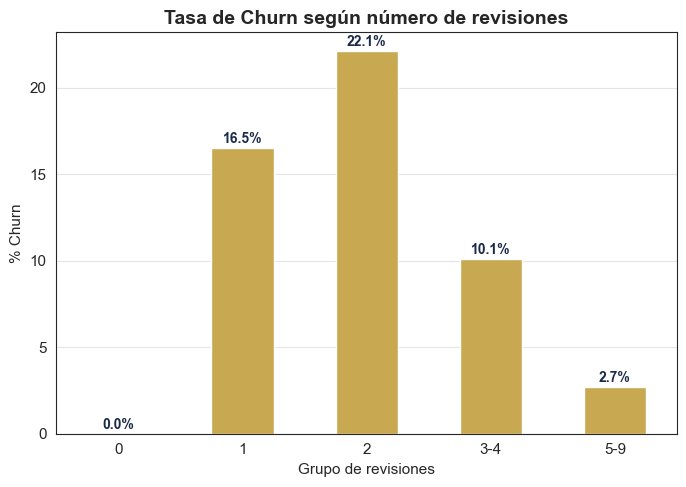

In [25]:
bins = [0, 1, 2, 3, 5, 10, 50]
labels_rev = ['0', '1', '2', '3-4', '5-9', '10+']
customer_data['Revisiones_grupo'] = pd.cut(customer_data['Revisiones'], bins=bins, labels=labels_rev, right=False)

churn_by_rev = customer_data.groupby('Revisiones_grupo', observed=True)['Churn_flag'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
churn_by_rev.plot(kind='bar', color=UAX_GOLD, edgecolor='white', ax=ax)
ax.set_title('Tasa de Churn según número de revisiones')
ax.set_xlabel('Grupo de revisiones')
ax.set_ylabel('% Churn')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y')

for i, v in enumerate(churn_by_rev):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, color=UAX_NAVY, fontweight='bold')

plt.tight_layout()
plt.show()


Cuanto más revisiones ha hecho un cliente, menor es su tasa de churn. Los clientes con 0 revisiones tienen la tasa más alta de abandono. Este patrón refuerza la idea de que **la relación postventa es clave para la retención**.


## 12. Efecto del Lead en la captación


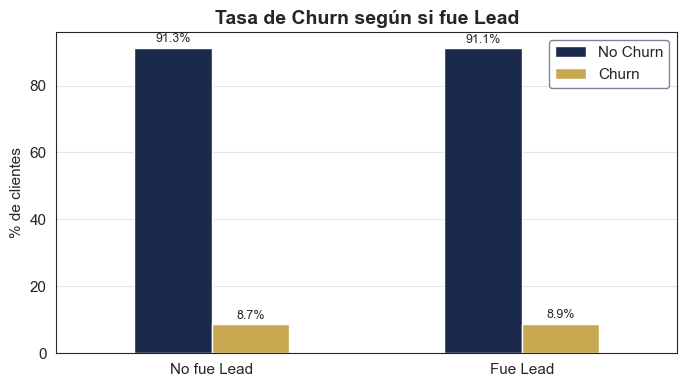

In [27]:
lead_churn = pd.crosstab(customer_data['Fue_Lead'], customer_data['Churn_400'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(7, 4))
lead_churn.plot(kind='bar', color=[UAX_NAVY, UAX_GOLD], ax=ax, edgecolor='white')
ax.set_title('Tasa de Churn según si fue Lead')
ax.set_xlabel('')
ax.set_xticklabels(['No fue Lead', 'Fue Lead'], rotation=0)
ax.set_ylabel('% de clientes')
ax.legend(['No Churn', 'Churn'])
ax.grid(axis='y')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=2)

plt.tight_layout()
plt.show()


Ser o no Lead parece tener un efecto modesto sobre el churn. Aunque pequeño, puede sumar como feature en el modelo predictivo.


## 13. Resumen de hallazgos


Tras esta exploración, estas son las **variables más relevantes** para predecir el churn:

| Variable | Relación con Churn | Importancia |
|---|---|---|
| `DAYS_LAST_SERVICE` | A más días sin servicio → más churn | ⭐⭐⭐ Alta |
| `EN_GARANTIA` | Sin garantía → mucho más churn | ⭐⭐⭐ Alta |
| `Revisiones` | Más revisiones → menos churn | ⭐⭐⭐ Alta |
| `EXTENSION_GARANTIA` | No extender → más churn | ⭐⭐ Media |
| `FORMA_PAGO` | Contado → más churn que financiado | ⭐⭐ Media |
| `SEGURO_BATERIA_LARGO_PLAZO` | No contratar → más churn | ⭐⭐ Media |
| `Origen` | Internet ligeramente más churn | ⭐ Baja |
| `PVP` / `Edad` | Sin relación clara | ➖ Baja |

El dataset está desbalanceado (~9% churn), lo que habrá que gestionar en la fase de modelado.
